# A. ĐỌC FILE ĐÃ QUA TIỀN XỬ LÝ

In [1]:
import pandas as pd
# Libraries
import numpy as np
import pandas as pd
from sklearn import *
from mlxtend.frequent_patterns import apriori, association_rules
from src.algorithms.clustering import KMeansSegmentation
# Visualization
from src.visualization import *

import run_preprocessing as rp

df_raw = rp.read_raw_data()
df_main = pd.read_pickle("data\\processed\\main_clean.pkl")
df_rules = pd.read_pickle("data\\processed\\rules_data.pkl")
df_users = pd.read_pickle("data\\processed\\user_profile.pkl")

In [2]:
df_users.info()

<class 'pandas.DataFrame'>
RangeIndex: 32216 entries, 0 to 32215
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   user_id          32216 non-null  str    
 1   total_orders     32216 non-null  int64  
 2   favorite_gems    32216 non-null  object 
 3   recency          32216 non-null  int64  
 4   avg_order_value  32216 non-null  float64
dtypes: float64(1), int64(2), object(1), str(1)
memory usage: 1.2+ MB


In [3]:
df_main.info()
# Bạn sẽ thấy các cột cũ như 'color', 'gem' biến mất
# Thay vào đó là hàng loạt cột mới như 'color_red', 'gem_diamond'...
display(df_main.head())

<class 'pandas.DataFrame'>
Index: 88007 entries, 0 to 95910
Data columns (total 74 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   event_time               88007 non-null  datetime64[us, UTC]
 1   order_id                 88007 non-null  str                
 2   product_id               88007 non-null  str                
 3   quantity                 88007 non-null  int64              
 4   category_id              88007 non-null  str                
 5   brand_id                 88007 non-null  str                
 6   price                    88007 non-null  float64            
 7   user_id                  88007 non-null  str                
 8   hour                     88007 non-null  int32              
 9   day                      88007 non-null  int32              
 10  month                    88007 non-null  int32              
 11  day_of_week              88007 non-null  int

,event_time,order_id,product_id,quantity,category_id,brand_id,price,user_id,hour,day,...,category_code_ring,category_code_souvenir,category_code_stud,category_code_unknown,price_segment_High,price_segment_Low,price_segment_Mid,price_scaled,quantity_scaled,hour_scaled
0,2018-12-01 11:40:29+00:00,1924719191579951782,1842195256808833386,1,1806829201890738522,0,561.51,1515915625207851155,11,1,...,0,0,0,0,1,0,0,0.136204,0.0,0.478261
1,2018-12-01 17:38:31+00:00,1924899396621697920,1806829193678291446,1,1806829201848795479,unknown,212.14,1515915625071969944,17,1,...,0,0,0,1,0,0,1,0.051308,0.0,0.739130
2,2018-12-02 13:53:42+00:00,1925511016616034733,1842214461889315556,1,1806829201915904347,1,54.66,1515915625048493557,13,2,...,0,0,0,0,0,1,0,0.013042,0.0,0.565217
3,2018-12-02 17:44:02+00:00,1925626951238681511,1835566849434059453,1,1806829201915904347,0,88.90,1515915625207630915,17,2,...,0,0,0,0,0,1,0,0.021362,0.0,0.739130
4,2018-12-02 21:30:19+00:00,1925740842841014667,1873936840742928865,1,1806829201924292956,0,417.67,1515915625175329378,21,2,...,0,0,0,0,0,0,1,0.101251,0.0,0.913043


# B. HUẤN LUYỆN MÔ HÌNH


In [3]:
segmentation = KMeansSegmentation(df_users)
df_clustered = segmentation.train(n_clusters=4)
df_profile = segmentation.profile_clusters()
display(df_profile)

,recency,total_orders,total_spend,avg_order_value,user_count,top_favorite_gems
cluster,,,,,,
0,180.00,1.38,754.79,581.64,14270,"[diamond, fianit, topaz, pearl]"
1,220.38,1.15,148.85,133.92,12561,"[fianit, diamond, topaz, pearl]"
2,190.27,16.05,8686.20,556.80,1969,"[diamond, fianit, topaz, pearl]"
3,695.46,1.52,511.97,348.08,3416,"[diamond, fianit, topaz, pearl]"


C:\Users\lttin\Desktop\DataMining\src\visualization.py:227: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\lttin\Desktop\DataMining\src\visualization.py:227: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\lttin\Desktop\DataMining\src\visualization.py:227: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\lttin\Desktop\DataMining\src\visualization.py:227: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for t

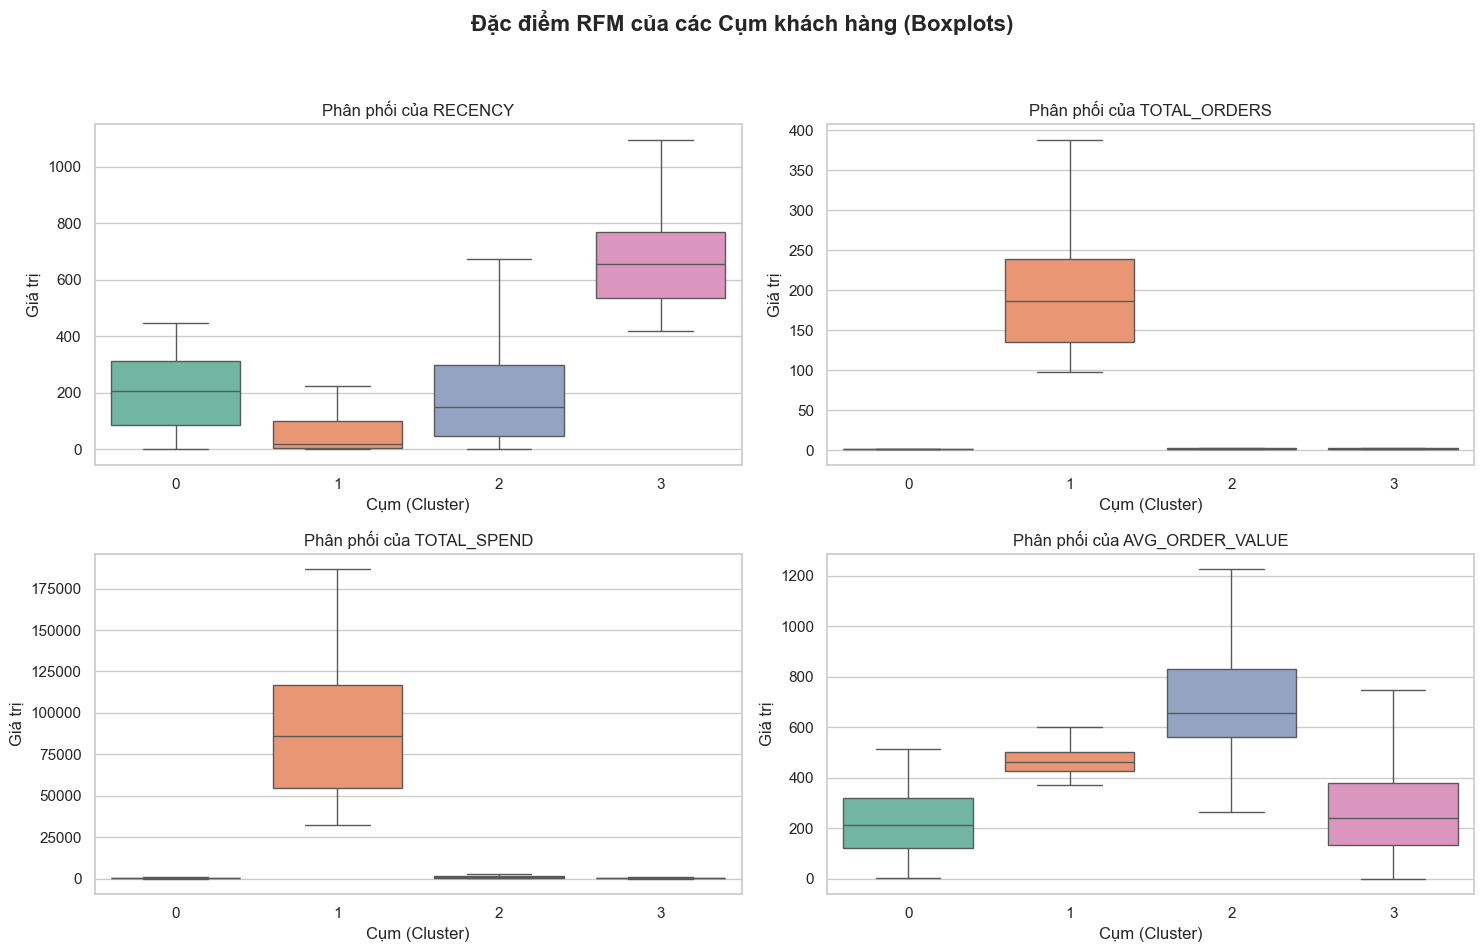

In [6]:
plot_cluster_boxplots(df_clustered)

Đã lưu biểu đồ tại: image\3d_scatter.png


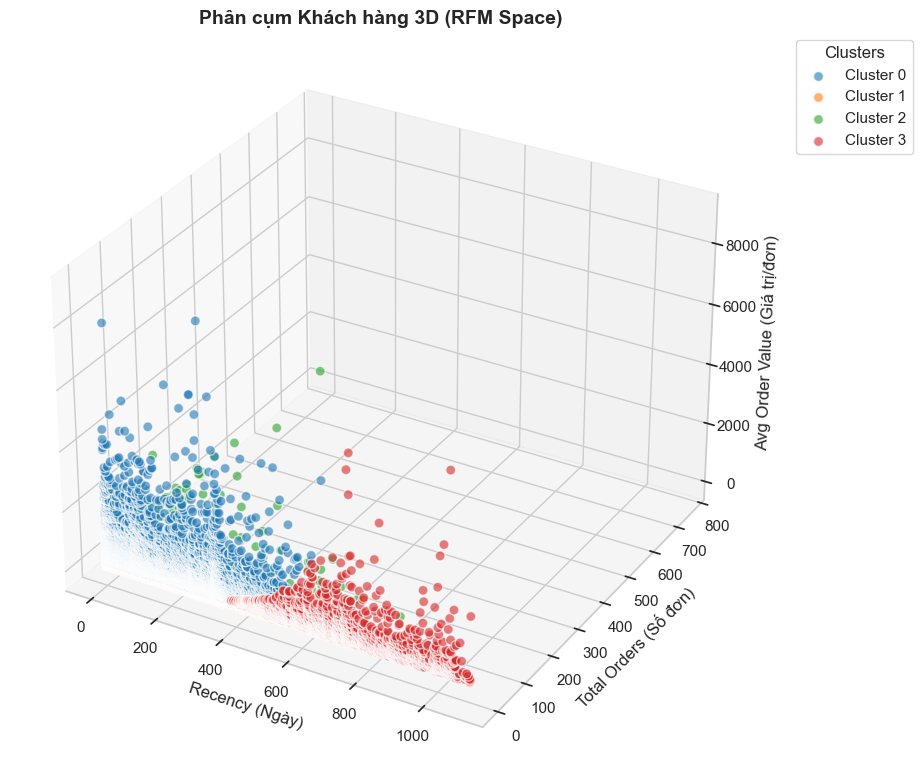

In [4]:
plot_rfm_3d_scatter(df_clustered, save_path="image\\3d_scatter.png")

# C. VẼ BIỂU ĐỒ

c:\Users\lttin\Desktop\DataMining\src\visualization.py:173: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Đã lưu biểu đồ tại: image\hours_in_day_trend


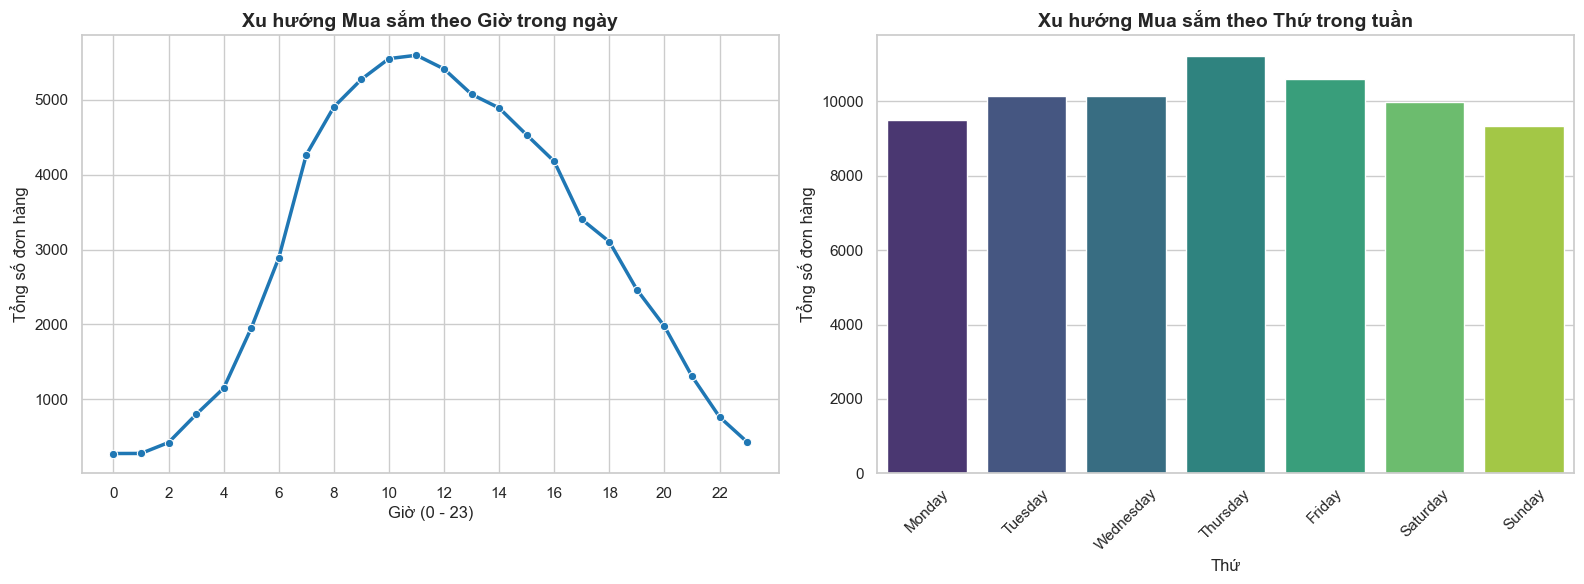

In [3]:
plot_temporal_trends(df_main, save_path="image\\hours_in_day_trend")